# NLP4RE - Testing
Este notebook permite visualizar qué está pasando por debajo del sistema: Base de datos, Embeddings, Chunks, y el proceso de RAG.


## 1. Configuración Inicial
Cargamos las variables de entorno y verificamos la conexión a la base de datos.


In [10]:
import os
import sys
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import requests

#add back path to import models
sys.path.append('../backend')

load_dotenv('.env')

API_URL = "http://localhost:8000"

print(f"Postgres Host: {os.getenv('POSTGRES_HOST')}")
print(f"LLM Provider: {os.getenv('LLM_PROVIDER')}")

#test api conection
try:
    response = requests.get(f"{API_URL}/health")
    print("API Health:", response.json())
except Exception as e:
    print("Error conectando a la API. Asegúrate de que los contenedores estén corriendo.")


Postgres Host: localhost
LLM Provider: None
API Health: {'api': 'ok', 'database': 'ok', 'llm_provider': 'local'}


## 2. Inspección de la Base de Datos
Vamos a conectarnos directamente a la base de datos para ver qué guardó el sistema.


In [11]:
# db conection
db_url = f"postgresql://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
engine = create_engine(db_url)

with engine.connect() as conn:
    # count requirements
    req_count = conn.execute(text("SELECT COUNT(*) FROM requirements")).scalar()
    print(f"Total de requisitos en BD: {req_count}")
    
    # count chunks by doc
    doc_count = conn.execute(text("SELECT COUNT(*) FROM documents")).scalar()
    print(f"Total de chunks (documentos) en BD: {doc_count}")


Total de requisitos en BD: 1315
Total de chunks (documentos) en BD: 1567


### 2.1. Viendo los Requisitos Guardados
Extraemos una muestra de los requerimientos para ver cómo los procesó y limpió el sistema antes de guardarlos.


In [12]:
query = "SELECT id, source_name, text, created_at FROM requirements LIMIT 5"
df_reqs = pd.read_sql(query, engine)
pd.set_option('display.max_colwidth', 150)
display(df_reqs)


,id,source_name,text,created_at
0,bba54c41-cf25-41f8-b59b-24e939c8790d,req-agendate.pdf,Requerimientos funcionales,2026-05-11 18:58:49.873643+00:00
1,be7ce8aa-25da-4d81-9f4f-7ba5dbe24c74,req-agendate.pdf,"RF-01 - Crear cita\nEl cliente podrá reservar una cita seleccionando servicio, proveedor, fecha y franja horaria.\nCriterio de aceptación: reserva...",2026-05-11 18:58:49.873712+00:00
2,8ff8910d-f71c-4bf1-bfdd-267013ea778a,req-agendate.pdf,"RF-02 - Consultar disponibilidad\nLa interfaz muestra la disponibilidad real del proveedor considerando plan de trabajo,\ndescansos, bloqueos y re...",2026-05-11 18:58:49.873749+00:00
3,288f8daa-34c7-4ff1-899e-fe6d3b0236b7,req-agendate.pdf,"RF-03 - Validación de reglas y conflictos\nToda petición de reserva pasa por validaciones: bloqueo por conflicto, mínimo tiempo de\nantelación, ve...",2026-05-11 18:58:49.873754+00:00
4,1efbf30b-ca54-489e-9dd1-d2479e269004,req-agendate.pdf,RF-04 - Reprogramar cita,2026-05-11 18:58:49.873758+00:00


### 2.2. Viendo los Chunks del Contexto Normativo
Verificamos los fragmentos de la ISO 29148. Notaremos cómo el texto fue dividido y almacenado.


In [13]:
query_docs = "SELECT id, source, page, chunk_index, content FROM documents LIMIT 5"
df_docs = pd.read_sql(query_docs, engine)
display(df_docs)


,id,source,page,chunk_index,content
0,7f148583-3efc-4576-bfbc-e8bf262d9eea,req-agendate.pdf,0,0,"Requerimientos funcionales\nRF-01 — Crear cita\nEl cliente podrá reservar una cita seleccionando servicio, proveedor, fecha y franja horaria.\nCri..."
1,90bc06c7-a997-40fc-b2a1-07e21e9b000c,req-agendate.pdf,0,1,"reglas se aplican uniformemente en UI y API.\nRF-04 — Reprogramar cita\nCliente, proveedor o administrador pueden cambiar fecha/hora/proveedor/ser..."
2,5d3eb8f7-c684-4e8a-af24-593b92cf71e3,req-agendate.pdf,0,2,"Proveedor/administrador pueden ver calendarios en vistas diaria, semanal y mensual; citas\ncodificadas por color; filtros por servicio/proveedor/e..."
3,5d2aa0aa-6c4f-4b12-a1c5-efa82a3f7e7c,req-agendate.pdf,1,3,"RF-08 — Crear plan de disponibilidad\nProveedor o administrador pueden registrar un plan de trabajo indicando días, horarios y\nreglas de atención..."
4,59397083-cb8c-4356-af0b-88d5cdde7563,req-agendate.pdf,1,4,"RF-09 — Gestión de servicios\nAdministrador puede crear/leer/actualizar/eliminar servicios (nombre, duración, precio,\ncategoría).\nCriterio de ac..."


## 3. Inspección de los Embeddings
La magia del RAG (Retrieval-Augmented Generation) ocurre gracias a los embeddings (vectores). Extraigamos los vectores para ver su dimensionalidad e inspeccionar cómo representan el texto.


In [14]:
# Vamos a extraer los embeddings. pgvector los almacena en un formato array.
# Convertiremos el string de vector '[0.1, 0.2, ...]' a una lista de Python
import numpy as np
import ast

query_emb = "SELECT id, text, embedding::text FROM requirements LIMIT 10"
df_embs = pd.read_sql(query_emb, engine)

# Convertir el string de vector a numpy array
df_embs['embedding'] = df_embs['embedding'].apply(lambda x: np.array(ast.literal_eval(x)) if x else None)

# Mostrar la dimensión del primer embedding
if not df_embs.empty and df_embs['embedding'].iloc[0] is not None:
    dim = len(df_embs['embedding'].iloc[0])
    print(f"Dimensionalidad de los embeddings: {dim} (Debería ser 768 para Gemini embedding-001 o 1536 para text-embedding-3-small)")
else:
    print("No hay embeddings para mostrar.")


Dimensionalidad de los embeddings: 768 (Debería ser 768 para Gemini embedding-001 o 1536 para text-embedding-3-small)


### 3.1. Visualización de los Embeddings (PCA)
Vamos a reducir la dimensionalidad a 2 dimensiones usando PCA para ver cómo se agrupan los requisitos en el espacio vectorial según su documento de origen.


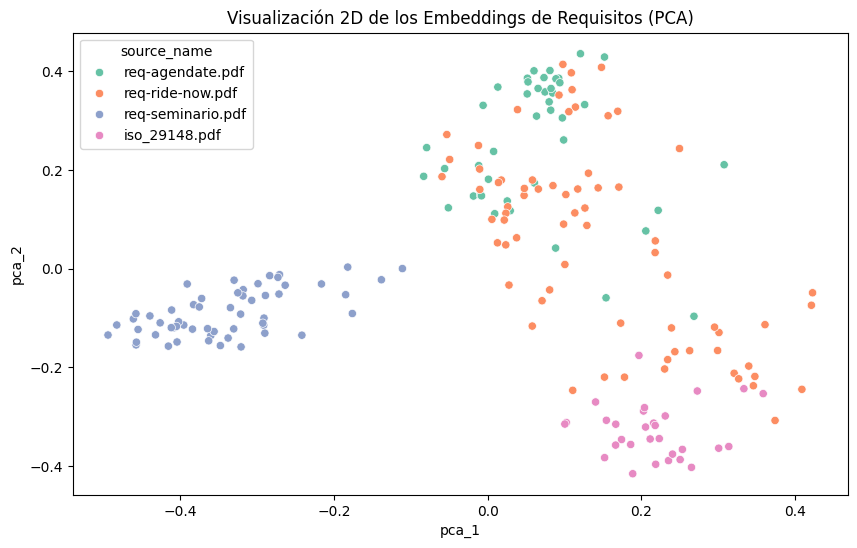

In [15]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

# Traer más requisitos con sus vectores y origen
query_plot = "SELECT source_name, embedding::text FROM requirements WHERE embedding IS NOT NULL LIMIT 200"
df_plot = pd.read_sql(query_plot, engine)

if not df_plot.empty:
    df_plot['embedding'] = df_plot['embedding'].apply(lambda x: np.array(ast.literal_eval(x)))
    X = np.stack(df_plot['embedding'].values)
    
    # Reducción a 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    df_plot['pca_1'] = X_pca[:, 0]
    df_plot['pca_2'] = X_pca[:, 1]
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_plot, x='pca_1', y='pca_2', hue='source_name', palette='Set2')
    plt.title('Visualización 2D de los Embeddings de Requisitos (PCA)')
    plt.show()
else:
    print("No hay suficientes datos para visualizar.")


## 4. Pruebas del Retriever (Similitud del Coseno)
Vamos a ver cómo pgvector recupera los chunks más relevantes para un requerimiento dado. Esto es clave porque el LLM usará este contexto para evaluar.


In [19]:
# Definimos un requerimiento de prueba
req_test = "El sistema debe tener un login seguro"

# Le pedimos al retriever que busque los 3 chunks normativos más similares
try:
    res = requests.post(f"{API_URL}/analyze", json={"text": req_test})
    if res.status_code == 200:
        data = res.json()
        print(f"Requerimiento: {req_test}\n")
        print("CONTEXTO RECUPERADO (TOP 3 CHUNKS):")
        print("-" * 50)
        for i, context in enumerate(data.get('context_used', [])):
            print(f"Chunk {i+1}:")
            # Imprimimos los primeros 300 caracteres del chunk
            print(context[:300] + "...")
            print("-" * 50)
except Exception as e:
    print(f"Error: {e}")




Requerimiento: El sistema debe tener un login seguro

CONTEXTO RECUPERADO (TOP 3 CHUNKS):
--------------------------------------------------
Chunk 1:
existence of log-on procedures and passwords and of data protection and recovery methods. This could
include the factors that would protect the system from accidental or malicious access, use, modification,
destruction or disclosure. Especially in safety-critical embedded systems this might incorpor...
--------------------------------------------------
Chunk 2:
Define the system security requirements related to both the facility that houses the system and
operational security requirements of the system itself. One example of security requirements might
be to specify the security and privacy requirements, including access limitations to the system, such as...
--------------------------------------------------
Chunk 3:
and usability;
j) provisions for safety, security, privacy, integrity and continuity of operations in emergencies; and
k) l

## 5. Pruebas End-to-End: Evaluación y Feedback
Finalmente, analizamos los resultados de la evaluación del LLM y las sugerencias que devuelve el sistema.


In [17]:
import json

if 'data' in locals() and data:
    print("EVALUACIÓN DEL LLM (ISO 29148):")
    print(json.dumps(data.get('evaluation', {}), indent=2, ensure_ascii=False))
    
    print("\n")
    print("FEEDBACK GENERADO:")
    print("Sugerencias:")
    for sug in data.get('feedback', {}).get('suggestions', []):
        print(f"- {sug}")
    print(f"\nRequerimiento Mejorado: {data.get('feedback', {}).get('improved_requirement')}")
